In [1]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


✓ PDF saved successfully to: figures/radial_chart.pdf
✓ This PDF is fully editable in Adobe Illustrator


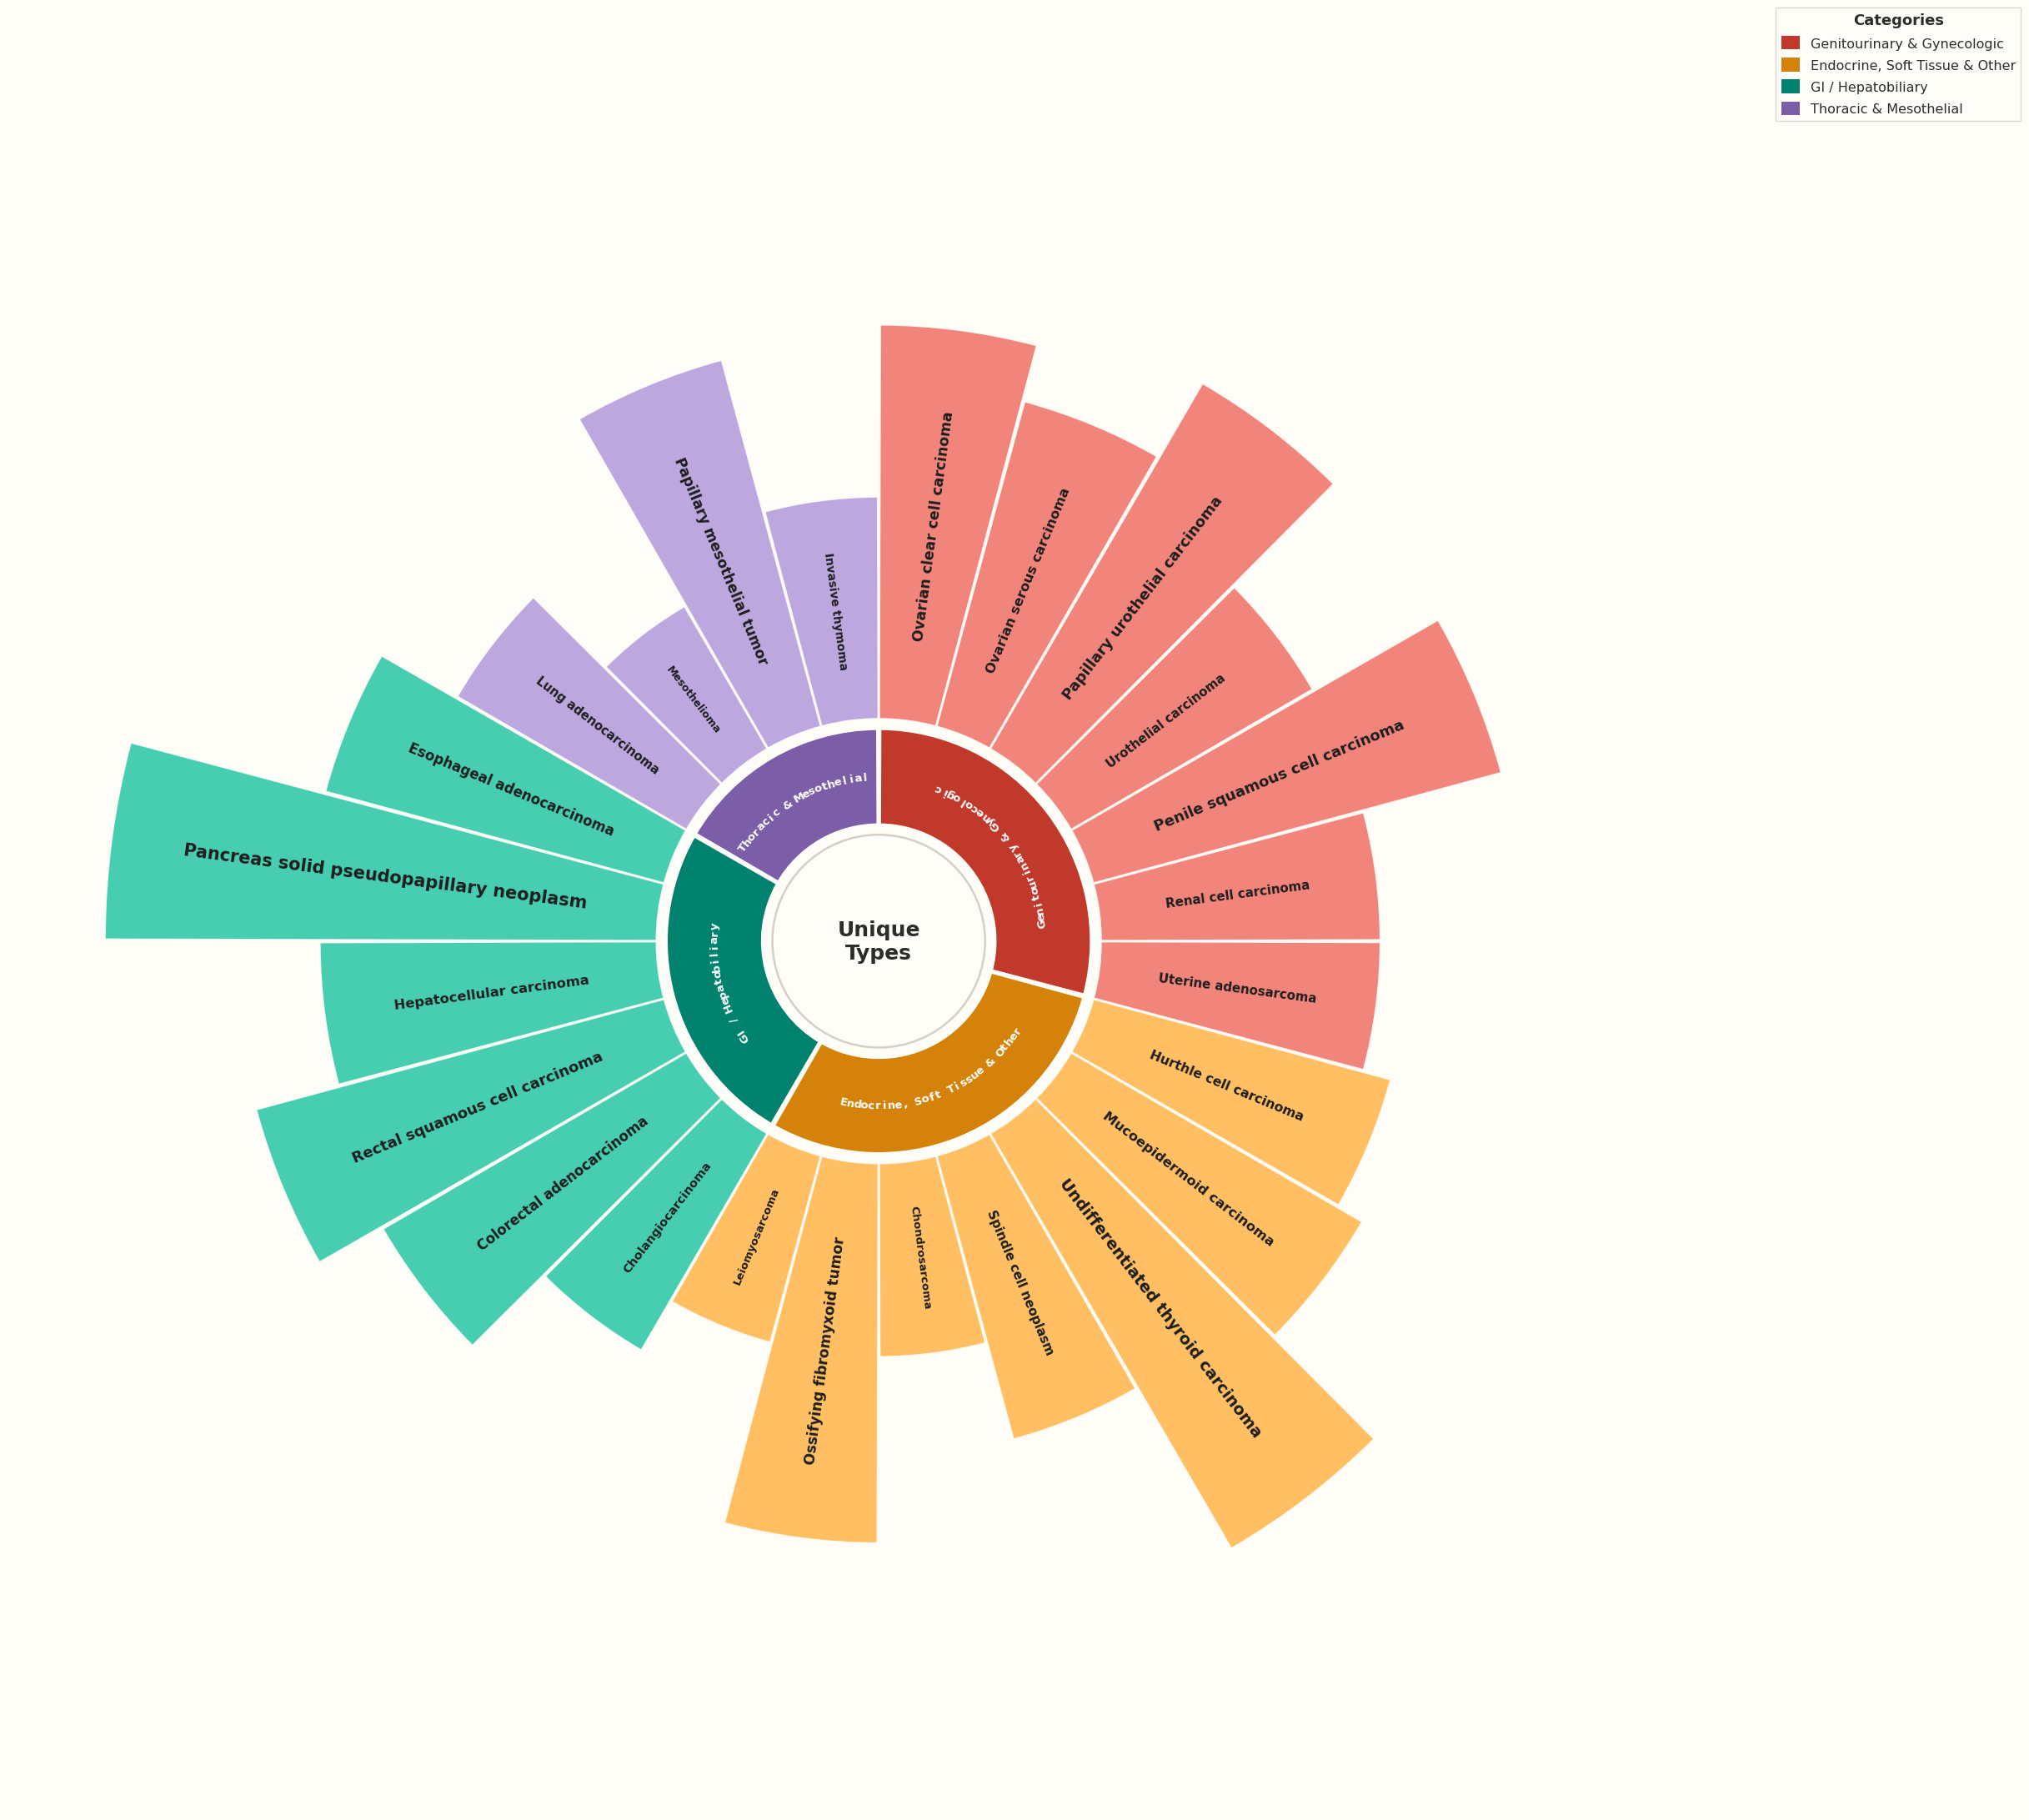

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge, Patch
from collections import defaultdict, Counter

# ==========================================
# DATA - 24 UNIQUE CANCER TYPES
# ==========================================
all_data = {
    'MOS001S1': 'Ovarian clear cell carcinoma',
    'MOS002S1': 'Cholangiocarcinoma',
    'MOS003S1': 'Colorectal adenocarcinoma',
    'MOS004S1': 'Rectal squamous cell carcinoma',
    'MOS008S1': 'Hurthle cell carcinoma',
    'MOS010S1': 'Lung adenocarcinoma',
    'MOS014S1': 'Ovarian serous carcinoma',
    'MOS015S1': 'Papillary urothelial carcinoma',
    'MOS027S1': 'Urothelial carcinoma',
    'MOS033S1': 'Mucoepidermoid carcinoma',
    'MOS034S1': 'Penile squamous cell carcinoma',
    'MOS042S1': 'Renal cell carcinoma',
    'MOS057S1': 'Mesothelioma',
    'MOS058S1': 'Hepatocellular carcinoma',
    'MOS060S1': 'Papillary mesothelial tumor',
    'MOS061S1': 'Pancreas solid pseudopapillary neoplasm',
    'MOS064S1': 'Esophageal adenocarcinoma',
    'MOS067S1': 'Undifferentiated thyroid carcinoma',
    'MOS078S1': 'Invasive thymoma',
    'MOS082S1': 'Spindle cell neoplasm',
    'MOS084S1': 'Uterine adenosarcoma',
    'MOS086S1': 'Chondrosarcoma',
    'MOS099S1': 'Ossifying fibromyxoid tumor',
    'MOS106S1': 'Leiomyosarcoma',
}

# ==========================================
# HELPERS - 4 GROUPS
# ==========================================
def categorize(cancer):
    c = cancer.lower().strip()

    # Group 1: GI / Hepatobiliary
    if any(x in c for x in ['colorectal', 'rectal', 'esophageal',
                             'cholangiocarcinoma', 'hepatocellular', 'pancreas']):
        return 'GI / Hepatobiliary'

    # Group 2: Genitourinary & Gynecologic
    elif any(x in c for x in ['urothelial', 'renal', 'penile',
                               'ovarian', 'uterine', 'cervical']):
        return 'Genitourinary & Gynecologic'

    # Group 3: Thoracic & Mesothelial
    elif any(x in c for x in ['lung', 'mesothelioma', 'mesothelial', 'thymoma']):
        return 'Thoracic & Mesothelial'

    # Group 4: Endocrine, Soft Tissue & Other
    else:
        return 'Endocrine, Soft Tissue & Other'

# ==========================================
# GROUP: category -> Counter of cancer_name -> count
# ==========================================
cat_types = defaultdict(Counter)
for cancer in all_data.values():
    cat_types[categorize(cancer)][cancer.strip()] += 1

# Sort categories by total count descending
sorted_cats = sorted(cat_types.items(), key=lambda x: -sum(x[1].values()))

total_cases = sum(sum(v.values()) for v in cat_types.values())

# ==========================================
# STYLE - 4 GROUPS
# ==========================================
colors_inner = {
    'GI / Hepatobiliary':             '#00826F',   # deep teal
    'Genitourinary & Gynecologic':    '#C0392B',   # deep red
    'Thoracic & Mesothelial':         '#7B5EA7',   # deep purple
    'Endocrine, Soft Tissue & Other': '#D4820A',   # deep amber
}

colors_outer = {
    'GI / Hepatobiliary':             '#2DC8A8',   # bright mint green
    'Genitourinary & Gynecologic':    '#F1756A',   # soft coral red
    'Thoracic & Mesothelial':         '#B39DDB',   # light lavender
    'Endocrine, Soft Tissue & Other': '#FFB74D',   # warm peach/amber
}

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(24, 24))
fig.patch.set_facecolor('#FFFDF8')
ax.set_facecolor('#FFFDF8')
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')

inner_r1, inner_r2 = 0.6, 1.1
outer_r1 = 1.15

# ---- label scaling ----
all_outer_labels = []
for cat, type_counter in sorted_cats:
    for name, count in type_counter.most_common():
        all_outer_labels.append(name)

min_len = min(len(l) for l in all_outer_labels)
max_len = max(len(l) for l in all_outer_labels)

def get_outer_radius(label):
    if max_len == min_len:
        norm = 0.5
    else:
        label_name = label.replace(" (1)", "").strip()
        norm = (len(label_name) - min_len) / (max_len - min_len)
    return 2.0 + norm * 2.0   # 2.0 … 4.0

def get_font_size(label):
    norm = (get_outer_radius(label) - 2.0) / 2.0
    return 9 + norm * 6       # 9 … 15

# ==========================================
# DRAWING
# ==========================================
cat_gap  = 0.5
type_gap = 0.3
current_angle = 90

for cat, type_counter in sorted_cats:
    cat_total      = sum(type_counter.values())
    color_in  = colors_inner.get(cat, '#888888')
    color_out = colors_outer.get(cat, '#AAAAAA')
    cat_angle_span = (cat_total / total_cases) * 360

    cat_start = current_angle
    cat_end   = current_angle - cat_angle_span

    # ---- inner wedge (category) ----
    wi_start = cat_start - cat_gap / 2
    wi_end   = cat_end   + cat_gap / 2

    if wi_start > wi_end:
        ax.add_patch(Wedge((0, 0), inner_r2, wi_end, wi_start,
                           width=(inner_r2 - inner_r1),
                           facecolor=color_in, edgecolor='#FFFDF8', linewidth=3.0))

        if (wi_start - wi_end) > 5:
            label_r = (inner_r1 + inner_r2) / 2
            mid_ang_deg = (wi_start + wi_end) / 2
        
            flip = (90 < mid_ang_deg % 360 < 270)
        
            txt = f"{cat}"
        
            char_width_rad = 0.042
            total_width_rad = len(txt) * char_width_rad
            start_offset = total_width_rad / 2
        
            mid_ang_rad = np.deg2rad(mid_ang_deg)
        
            for i, ch in enumerate(txt):
                if flip:
                    char_ang_rad = mid_ang_rad + (start_offset - (i + 0.5) * char_width_rad)
                    rotation = np.rad2deg(char_ang_rad) - 90
                else:
                    char_ang_rad = mid_ang_rad - (start_offset - (i + 0.5) * char_width_rad)
                    rotation = np.rad2deg(char_ang_rad) + 90
        
                x = label_r * np.cos(char_ang_rad)
                y = label_r * np.sin(char_ang_rad)
        
                ax.text(x, y, ch,
                        ha='center', va='center', fontsize=9.5, fontweight='bold',
                        color='white', rotation=rotation)

    # ---- outer wedges (one per distinct type) ----
    cur = cat_start
    for type_name, type_count in type_counter.most_common():
        span = (type_count / total_cases) * 360

        wo_start = cur          - type_gap / 2
        wo_end   = (cur - span) + type_gap / 2

        label = type_name
        r2    = get_outer_radius(f"{label} (1)")
        fs    = get_font_size(f"{label} (1)")

        if wo_start > wo_end:
            ax.add_patch(Wedge((0, 0), r2, wo_end, wo_start,
                               width=(r2 - outer_r1),
                               facecolor=color_out, edgecolor='#FFFDF8',
                               linewidth=1.2, alpha=0.88))

            mid_ang     = (wo_start + wo_end) / 2
            mid_ang_rad = np.deg2rad(mid_ang)
            label_r     = (outer_r1 + r2) / 2
            x = label_r * np.cos(mid_ang_rad)
            y = label_r * np.sin(mid_ang_rad)

            rotation = mid_ang
            if 90 < mid_ang % 360 < 270:
                rotation += 180

            ax.text(x, y, label,
                    ha='center', va='center', fontsize=fs, fontweight='bold',
                    color='#1E1E1E',
                    rotation=rotation, rotation_mode='anchor')

        cur -= span

    current_angle -= cat_angle_span

# ==========================================
# CENTER CIRCLE & LEGEND
# ==========================================
ax.add_patch(plt.Circle((0, 0), 0.55, facecolor='#FFFDF8',
                         edgecolor='#D6CFC3', linewidth=1.8, zorder=5))
ax.text(0, 0, "Unique\nTypes", ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2C2C2C', zorder=6)

legend_elements = [Patch(facecolor=colors_inner.get(cat, '#888888'),
                         edgecolor='none', label=cat)
                   for cat, _ in sorted_cats]
leg = ax.legend(handles=legend_elements, loc='upper right',
                bbox_to_anchor=(1.16, 1.04),
                frameon=True, fancybox=False, edgecolor='#D6CFC3',
                facecolor='#FFFDF8', fontsize=11.5,
                title='Categories', title_fontsize=13,
                labelspacing=0.6, handlelength=1.4, handleheight=1.2)
leg.get_title().set_fontweight('bold')
leg.get_title().set_color('#2C2C2C')
for t in leg.get_texts():
    t.set_color('#2C2C2C')

# plt.title("Unique Cancer Type Distribution (24 Types, 4 Groups)", fontsize=22,
#           fontweight='bold', pad=35, color='#2C2C2C')
plt.tight_layout()

# ==========================================
# 3. EXPORT TO PDF
# ==========================================
output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

pdf_path = os.path.join(output_dir, "radial_chart.pdf")

# Save as PDF with vector format (suitable for Adobe Illustrator)
# Use TrueType fonts (editable text in Illustrator, not converted to paths)
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts
plt.rcParams['ps.fonttype'] = 42

plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight', 
            facecolor='#FFFDF8', edgecolor='none')

print(f"✓ PDF saved successfully to: {pdf_path}")
print(f"✓ This PDF is fully editable in Adobe Illustrator")

plt.show()